# Conical flow — all methods, all results

**Ehsan Roohi · Project 1 · 2026 Python edition**

Use **Runtime → Run all** to display the complete executed comparison:

- **All 11 numerical fluxes** at Mach 2.35 and 7.95, and for both viscous thermal walls: **44 flow results**.
- **Six FV reconstruction choices**, including characteristic CWENO3/5.
- **Twelve higher-order viscous/grid cases** and **six optional DG cases**.
- Physical properties, separate convergence figures, per-method status tables, wall shear and heat transfer.

The initial figures load **previously executed numerical runs**; they are not recomputed in this session.
Optional fresh runs follow the complete comparisons. Setup is collapsed, and no encoded source block is displayed.
Numerical algorithms remain ordinary, editable Python files.

[Source](https://github.com/Ehsan-Roohi/Ehsan-Roohi/blob/main/courses/cfd-2/modern-python/conical/README.md) · [Full report](https://github.com/Ehsan-Roohi/Ehsan-Roohi/blob/main/courses/cfd-2/modern-python/conical/RESULTS.md) · [Viscous equations](https://github.com/Ehsan-Roohi/Ehsan-Roohi/blob/main/courses/cfd-2/modern-python/conical/VISCOUS.md) · [DG companion](https://github.com/Ehsan-Roohi/Ehsan-Roohi/blob/main/courses/cfd-2/modern-python/conical/DG.md)


In [1]:
# @title Start the CFD workspace {display-mode: "form"}
# @markdown Run once to prepare numerical modules and executed study data.
import io, json, sys, hashlib, zipfile, importlib.util, subprocess
from pathlib import Path
from urllib.request import urlopen
missing = [p for p in ("numpy", "matplotlib") if importlib.util.find_spec(p) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
RUNTIME_URL = 'https://raw.githubusercontent.com/Ehsan-Roohi/Ehsan-Roohi/main/courses/cfd-2/downloads/conical-colab-runtime-7046ca2991b6.zip'
RUNTIME_SHA256 = '7046ca2991b6a83f330c932ce3a1cacfbb5d5951ec02f0926f6ef068176fd574'
data = urlopen(RUNTIME_URL, timeout=90).read()
assert hashlib.sha256(data).hexdigest() == RUNTIME_SHA256
WORK = (Path("/content") if Path("/content").exists() else Path.cwd()) / "conical-modern"
WORK.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(io.BytesIO(data)) as z:
    for name in z.namelist():
        path = (WORK / name).resolve()
        if not path.is_relative_to(WORK.resolve()):
            raise ValueError("Invalid package path")
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_bytes(z.read(name))
sys.path.insert(0, str(WORK))
from notebook_dashboard import (load_study, select, show_table, plot_properties,
    plot_convergence, plot_wall_transport, plot_method_cards)
from colab_api import run_case
from flux import FLUXES
study = load_study()
assert len(select(study, physics="inviscid", mach=2.35)) == 11
print("Ready: all 11 fluxes, six reconstruction choices, viscous and DG results.")


Ready: all 11 fluxes, six reconstruction choices, viscous and DG results.


## Which methods are here?

| Family | Implemented choices | Results |
|---|---|---|
| Face flux | Roe, Van Leer, HLLC, HLLE, Rusanov, AUSM, AUSM+, AUSM+-up, AUSM+-up2, SLAU2, EC+LF | Four 11-method comparisons |
| FV reconstruction | Constant, MUSCL-MC, CWENO3/5, characteristic CWENO3/5 | Six-method comparison |
| Viscous interior operator | Order 2 and order 4 on stretched FV meshes | Wall transport and grid/operator study |
| Thermal wall | Adiabatic and isothermal, both no-slip | Separate viscous sections |
| High-order companion | Modal DG degrees 0, 1 and 2 | Six-run DG comparison |

Fluxes, reconstructions and diffusion operators are different algorithm components that can be combined.
DG is a separate discretization. FR/Radau equivalence is checked for linear advection; a full FR cone solver is not implemented.
No turbulence, real-gas or chemistry model is included.

Several fluxes predict almost the same discretized flow, so curves can overlap. **Every flux has its own panel below**,
and every case has an 11-row table; no method is silently omitted.


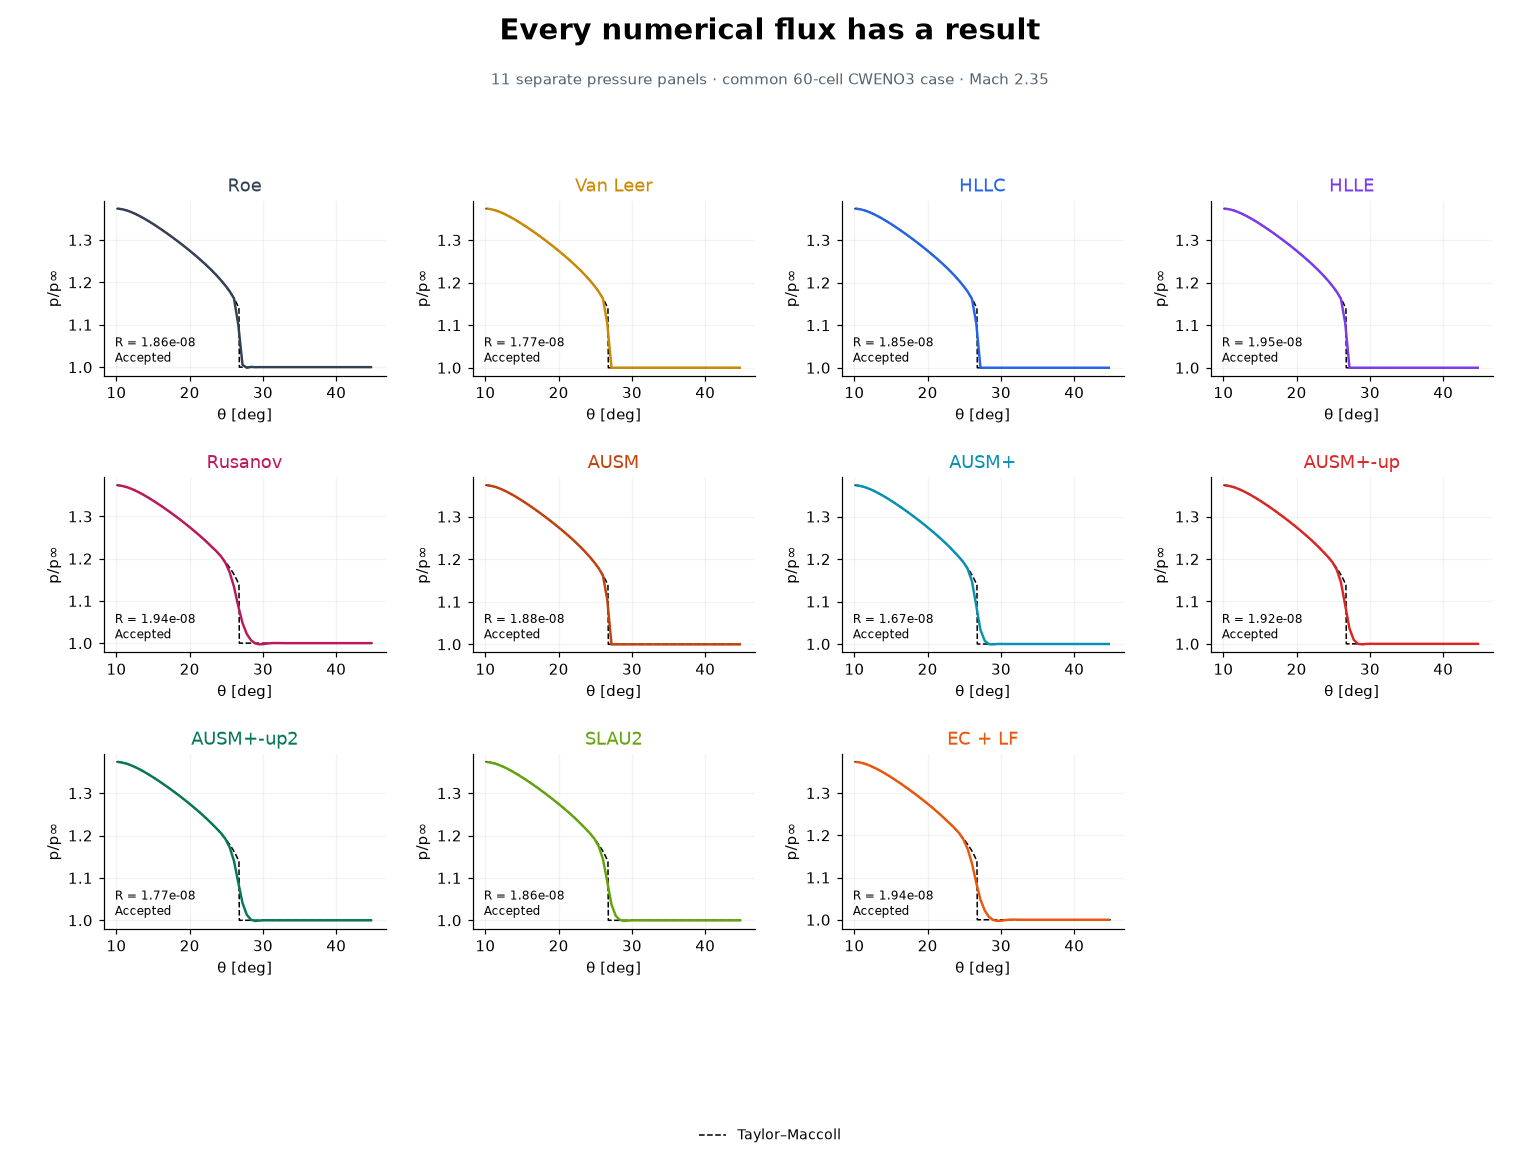

Flux,Reconstruction,Cells,Status,Final residual,p wall / p∞
Roe,cweno3,60,Accepted,1.855e-08,1.3738719
Van Leer,cweno3,60,Accepted,1.771e-08,1.3739058
HLLC,cweno3,60,Accepted,1.847e-08,1.3738895
HLLE,cweno3,60,Accepted,1.946e-08,1.3738887
Rusanov,cweno3,60,Accepted,1.938e-08,1.3736387
AUSM,cweno3,60,Accepted,1.879e-08,1.3739009
AUSM+,cweno3,60,Accepted,1.673e-08,1.3736575
AUSM+-up,cweno3,60,Accepted,1.920e-08,1.3736235
AUSM+-up2,cweno3,60,Accepted,1.774e-08,1.3737289
SLAU2,cweno3,60,Accepted,1.857e-08,1.3735317


In [2]:
inviscid_low = select(study, physics="inviscid", mach=2.35)
plot_method_cards(inviscid_low)
show_table(inviscid_low)


## 1. Inviscid cone · Mach 2.35 · all 11 fluxes

Common 60-cell CWENO3 discretization, cone 10°, outer angle 45°.
Taylor–Maccoll is the independent reference. The six physical properties are followed immediately by a separate convergence figure.
Solid lines passed the gate; dotted † lines did not. Failed answers and histories remain visible.


Flux,Reconstruction,Cells,Status,Final residual,p wall / p∞
Roe,cweno3,60,Accepted,1.855e-08,1.3738719
Van Leer,cweno3,60,Accepted,1.771e-08,1.3739058
HLLC,cweno3,60,Accepted,1.847e-08,1.3738895
HLLE,cweno3,60,Accepted,1.946e-08,1.3738887
Rusanov,cweno3,60,Accepted,1.938e-08,1.3736387
AUSM,cweno3,60,Accepted,1.879e-08,1.3739009
AUSM+,cweno3,60,Accepted,1.673e-08,1.3736575
AUSM+-up,cweno3,60,Accepted,1.920e-08,1.3736235
AUSM+-up2,cweno3,60,Accepted,1.774e-08,1.3737289
SLAU2,cweno3,60,Accepted,1.857e-08,1.3735317


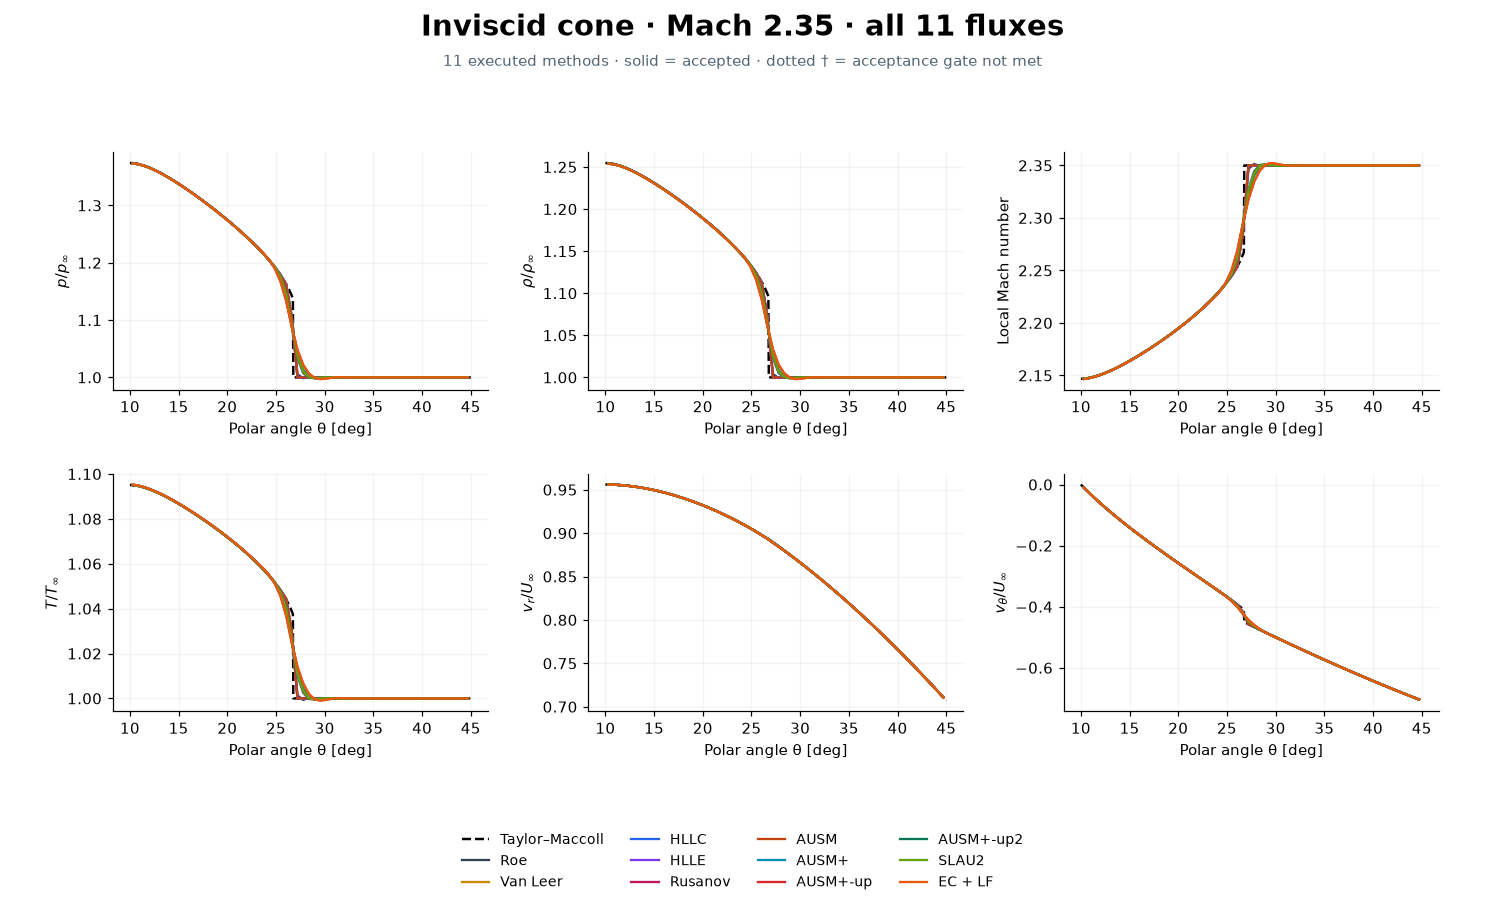

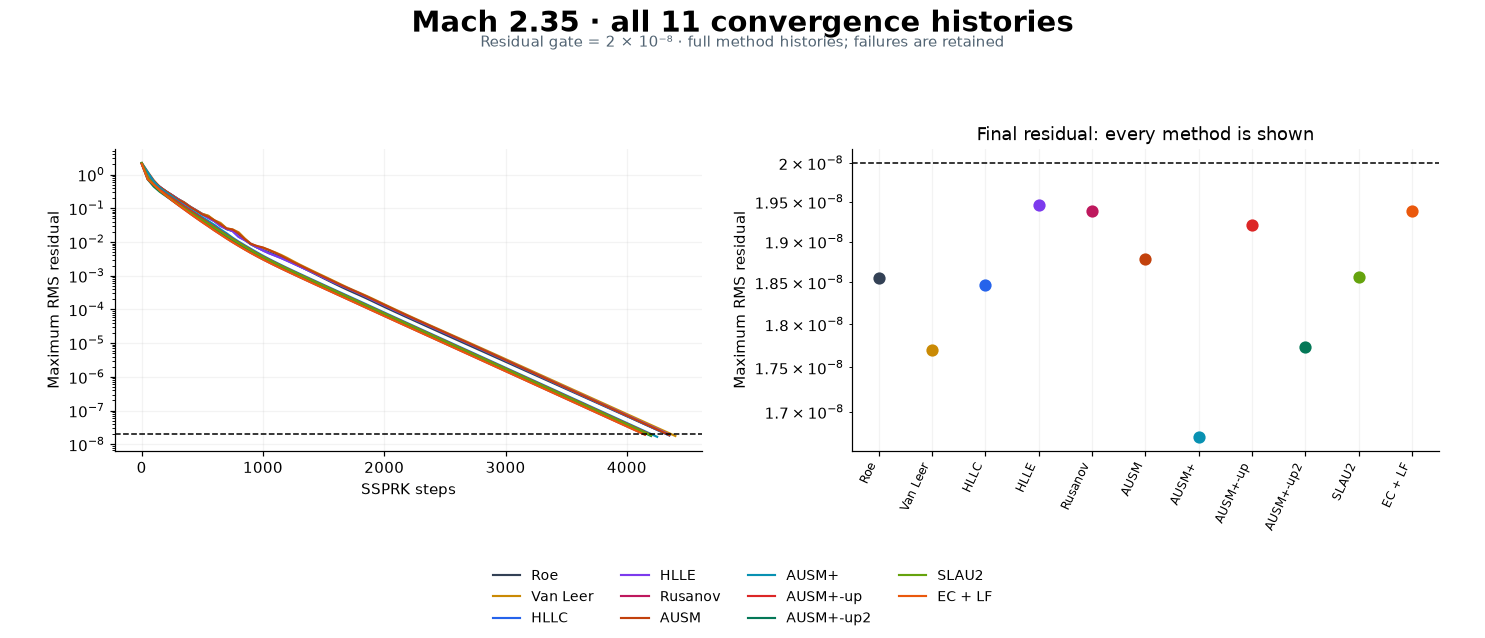

In [3]:
inviscid_low = select(study, physics="inviscid", mach=2.35)
show_table(inviscid_low)
plot_properties(inviscid_low, "inviscid-m2.35-properties", "Inviscid cone · Mach 2.35 · all 11 fluxes")
plot_convergence(inviscid_low, "inviscid-m2.35-convergence", "Mach 2.35 · all 11 convergence histories")


## 2. Inviscid cone · Mach 7.95 · all 11 fluxes

Common 60-cell CWENO3 discretization, cone 10°, outer angle 22°.
Taylor–Maccoll is the independent reference. The six physical properties are followed immediately by a separate convergence figure.
Solid lines passed the gate; dotted † lines did not. Failed answers and histories remain visible.


Flux,Reconstruction,Cells,Status,Final residual,p wall / p∞
Roe,cweno3,60,Accepted,1.682e-08,4.0251306
Van Leer,cweno3,60,Accepted,1.770e-08,4.0244689
HLLC,cweno3,60,Accepted,1.696e-08,4.0152687
HLLE,cweno3,60,Accepted,1.919e-08,4.0138925
Rusanov,cweno3,60,Gate not met,5.866e-01,3.9891349
AUSM,cweno3,60,Accepted,1.870e-08,4.0275752
AUSM+,cweno3,60,Gate not met,4.079e-01,4.0078997
AUSM+-up,cweno3,60,Gate not met,2.299e-01,4.0029219
AUSM+-up2,cweno3,60,Gate not met,1.149e+00,4.1213403
SLAU2,cweno3,60,Gate not met,6.363e-01,3.9582394


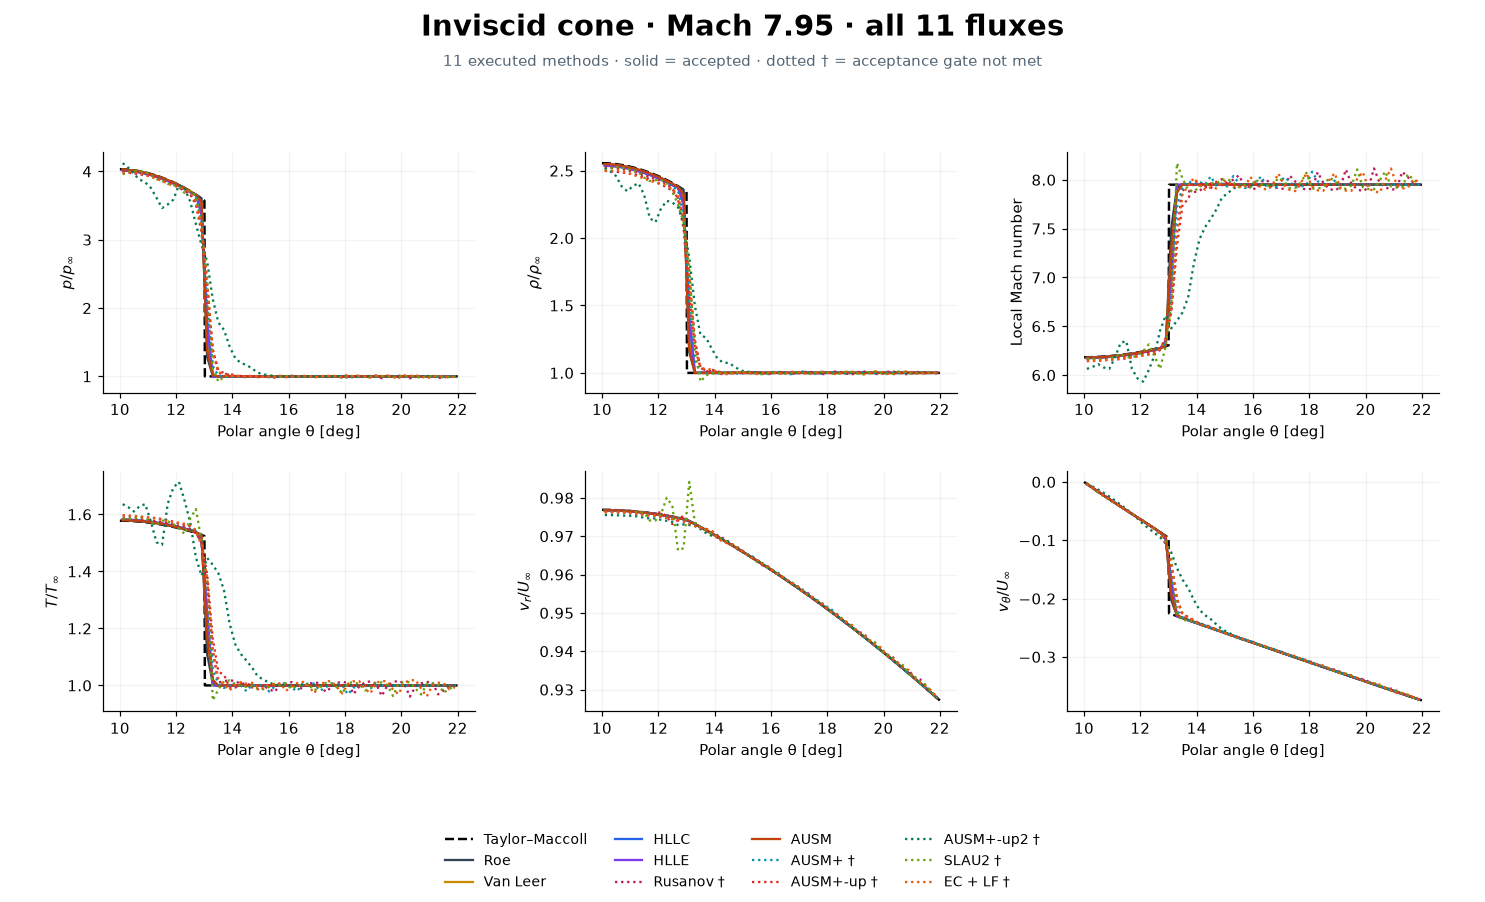

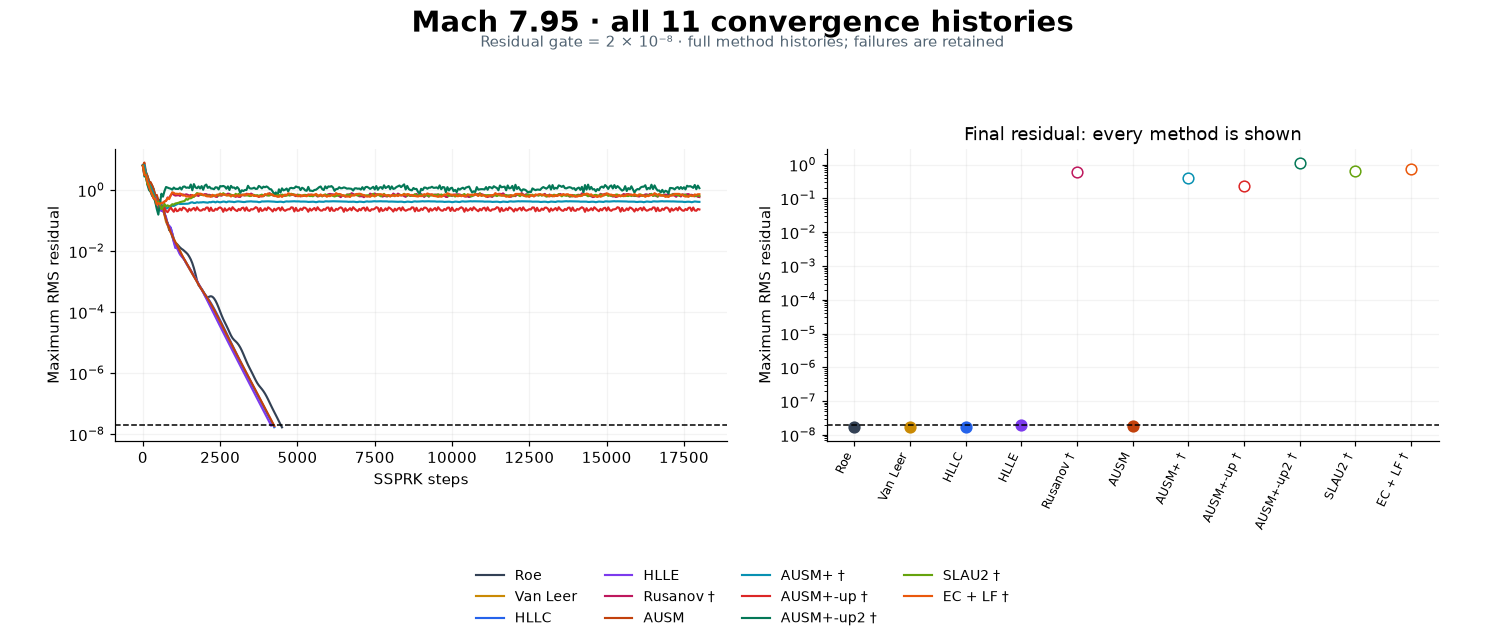

In [4]:
inviscid_high = select(study, physics="inviscid", mach=7.95)
show_table(inviscid_high)
plot_properties(inviscid_high, "inviscid-m7.95-properties", "Inviscid cone · Mach 7.95 · all 11 fluxes")
plot_convergence(inviscid_high, "inviscid-m7.95-convergence", "Mach 7.95 · all 11 convergence histories")


## 3. Viscous cone station · adiabatic wall · all 11 fluxes

Mach 7.95, Re = 420,000, Pr = 0.72, 60 wall-clustered cells, primitive-minmod, second-order interior diffusion and a no-slip wall.
Adiabatic heat flux is zero and wall temperature is predicted.

These are **local radial-station angular predictions**, not downstream boundary-layer growth.
The final comparison uses configuration-matched continuations where required; initial attempts remain archived.
All methods use the same wall-matched coarse seed; seeded iteration counts are not fair speed rankings.


Flux,Reconstruction,Cells,Status,Final residual,p wall / p∞,Cf,q wall into fluid
Roe,primitive-minmod,60,Accepted,1.385e-08,4.3353837,0.00386926,-0
Van Leer,primitive-minmod,60,Accepted,1.870e-10,4.3462328,0.00433541,-0
HLLC,primitive-minmod,60,Accepted,4.383e-09,4.3218807,0.00386231,-0
HLLE,primitive-minmod,60,Accepted,2.556e-10,4.3491459,0.00474366,-0
Rusanov,primitive-minmod,60,Accepted,1.365e-08,4.3190811,0.00472789,-0
AUSM,primitive-minmod,60,Accepted,1.794e-08,4.3356708,0.00386745,-0
AUSM+,primitive-minmod,60,Accepted,9.244e-09,4.3054200,0.00385452,-0
AUSM+-up,primitive-minmod,60,Accepted,1.831e-08,4.3048082,0.00385396,-0
AUSM+-up2,primitive-minmod,60,Accepted,6.253e-09,4.3075167,0.00385088,-0
SLAU2,primitive-minmod,60,Accepted,1.576e-08,4.3096384,0.00385464,-0


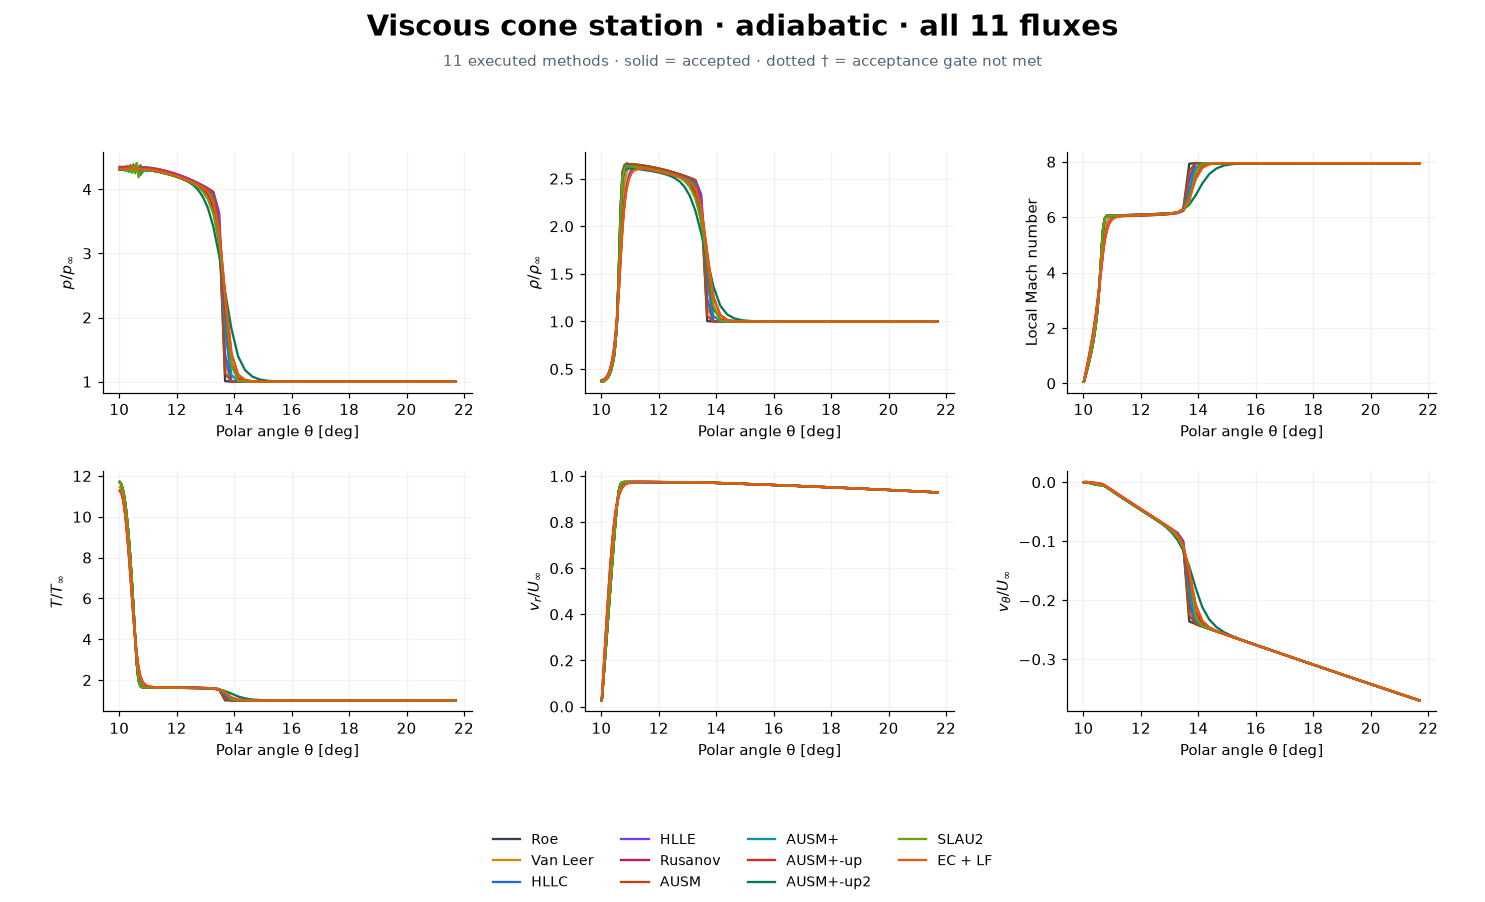

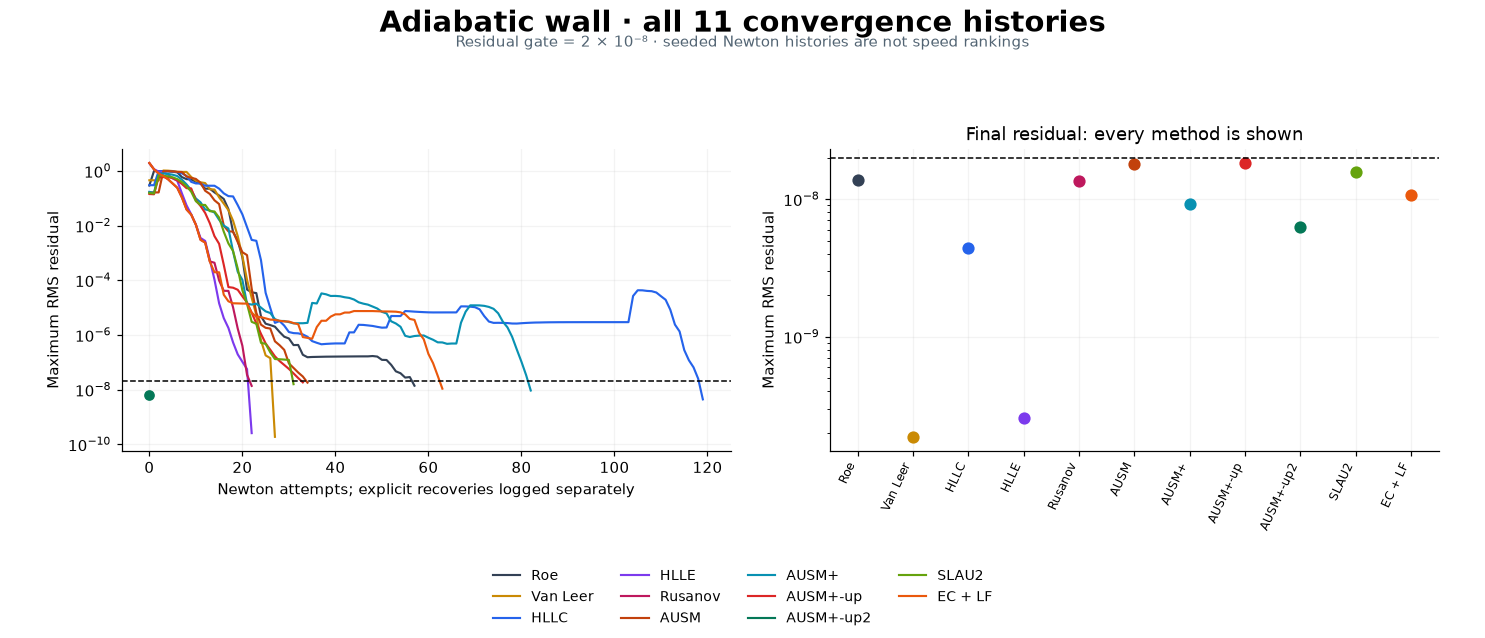

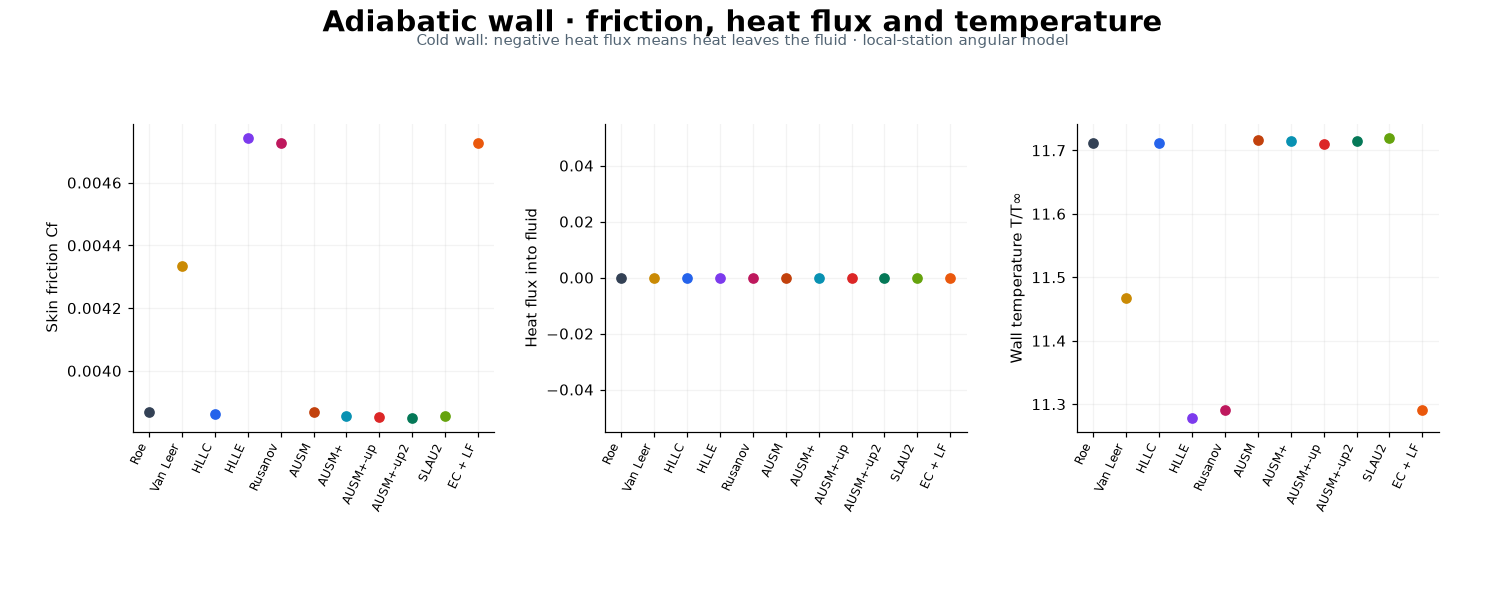

In [5]:
adiabatic_runs = select(study, physics='adiabatic')
show_table(adiabatic_runs)
plot_properties(adiabatic_runs, "adiabatic-properties", "Viscous cone station · adiabatic · all 11 fluxes")
plot_convergence(adiabatic_runs, "adiabatic-convergence", "Adiabatic wall · all 11 convergence histories")
plot_wall_transport(adiabatic_runs, "adiabatic-wall-transport", "Adiabatic wall · friction, heat flux and temperature")


## 4. Viscous cone station · isothermal wall · all 11 fluxes

Mach 7.95, Re = 420,000, Pr = 0.72, 60 wall-clustered cells, primitive-minmod, second-order interior diffusion and a no-slip wall.
The cold isothermal wall fixes T_wall/T∞ = 1; negative heat flux means heat leaves the fluid.

These are **local radial-station angular predictions**, not downstream boundary-layer growth.
The final comparison uses configuration-matched continuations where required; initial attempts remain archived.
All methods use the same wall-matched coarse seed; seeded iteration counts are not fair speed rankings.


Flux,Reconstruction,Cells,Status,Final residual,p wall / p∞,Cf,q wall into fluid
Roe,primitive-minmod,60,Accepted,1.076e-08,4.1249651,0.00408754,-0.00108896
Van Leer,primitive-minmod,60,Accepted,1.602e-11,4.1351481,0.00511088,-0.00142691
HLLC,primitive-minmod,60,Accepted,1.905e-08,4.1164823,0.00408328,-0.00108802
HLLE,primitive-minmod,60,Accepted,2.287e-10,4.1595695,0.00583022,-0.00160121
Rusanov,primitive-minmod,60,Accepted,1.990e-08,4.1217361,0.00580823,-0.00159755
AUSM,primitive-minmod,60,Accepted,1.526e-08,4.1305247,0.00408899,-0.00108949
AUSM+,primitive-minmod,60,Accepted,1.597e-08,4.1053175,0.00407709,-0.00108641
AUSM+-up,primitive-minmod,60,Accepted,1.618e-08,4.1053805,0.00407623,-0.00108636
AUSM+-up2,primitive-minmod,60,Accepted,1.379e-08,4.1056293,0.00407281,-0.00108615
SLAU2,primitive-minmod,60,Accepted,1.916e-08,4.1051882,0.00407524,-0.00108623


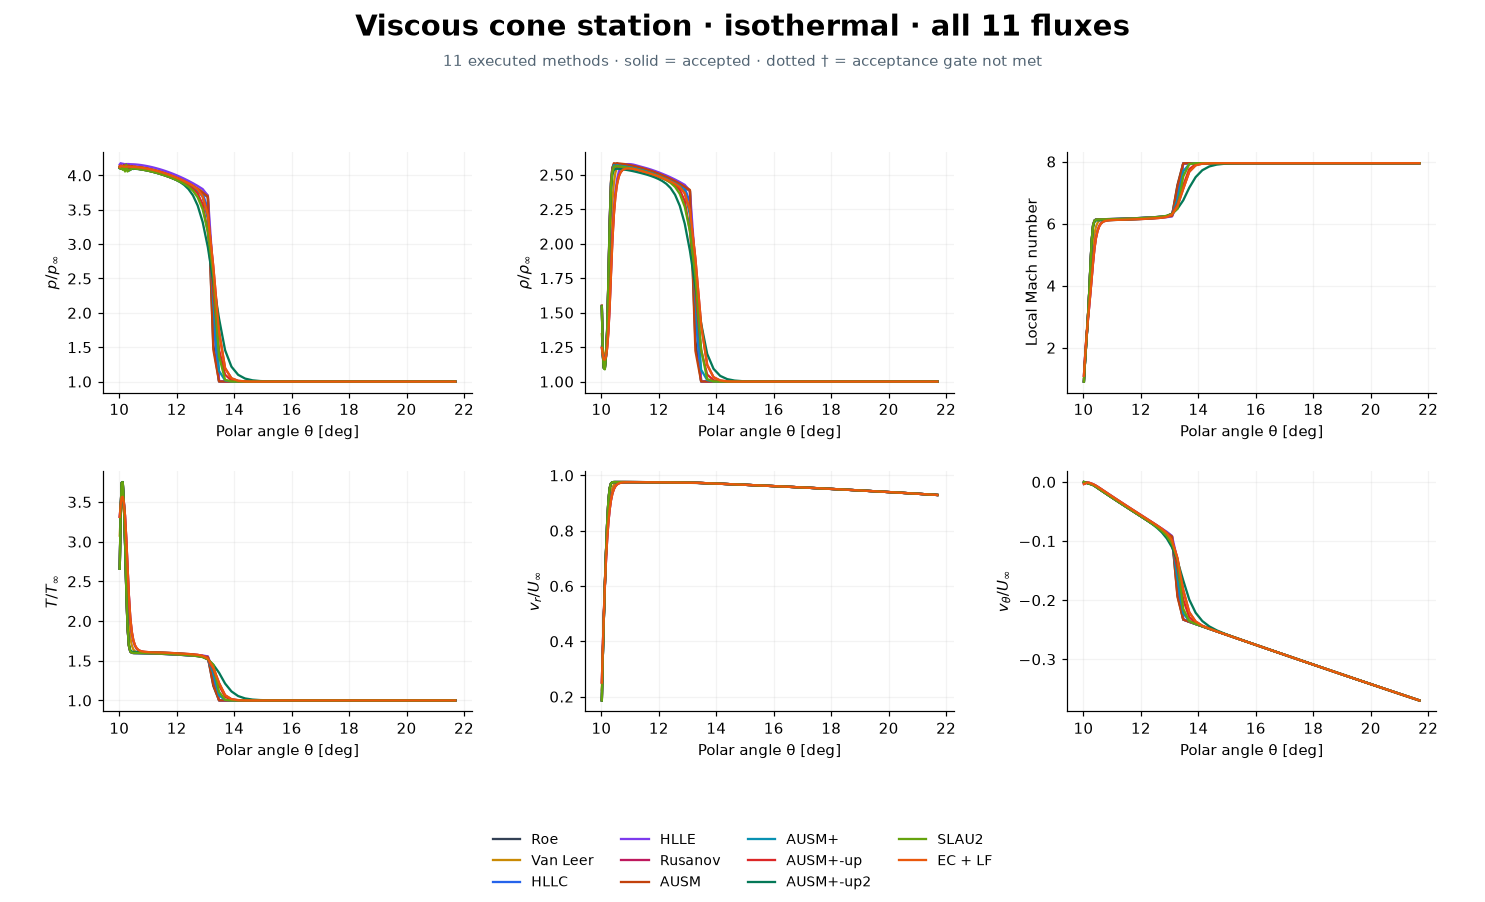

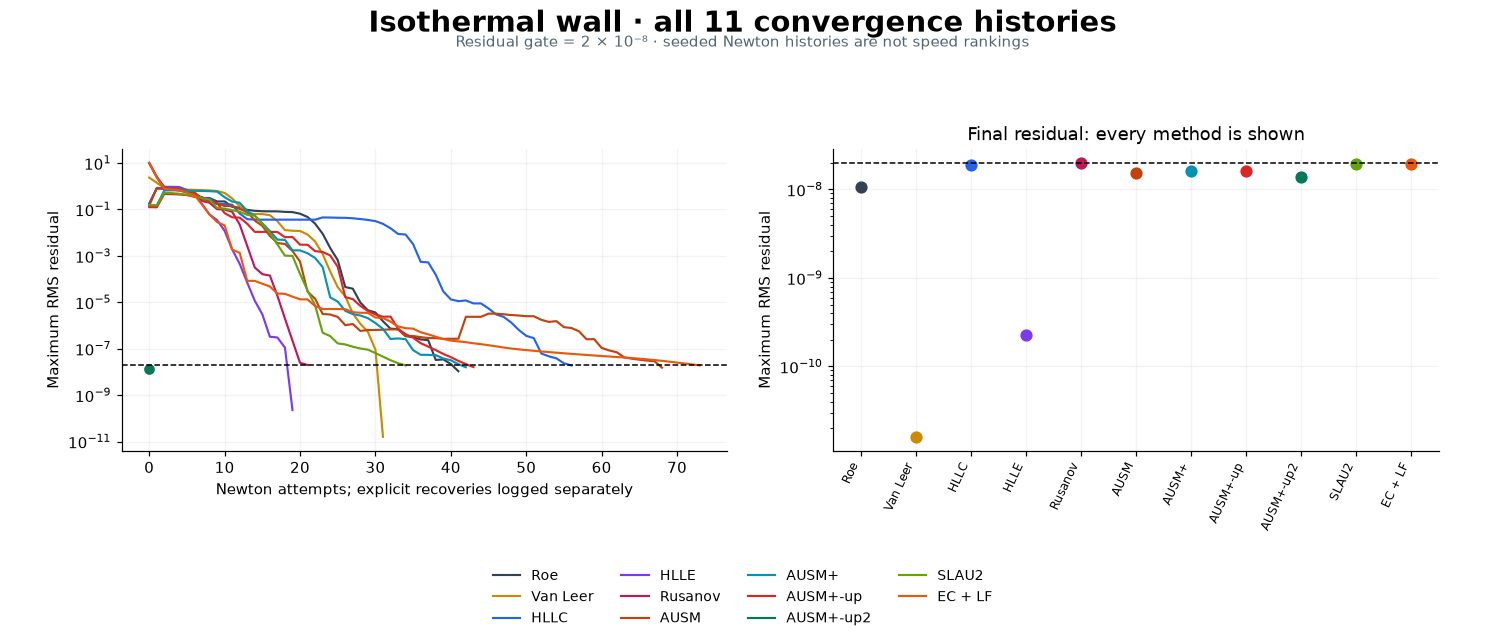

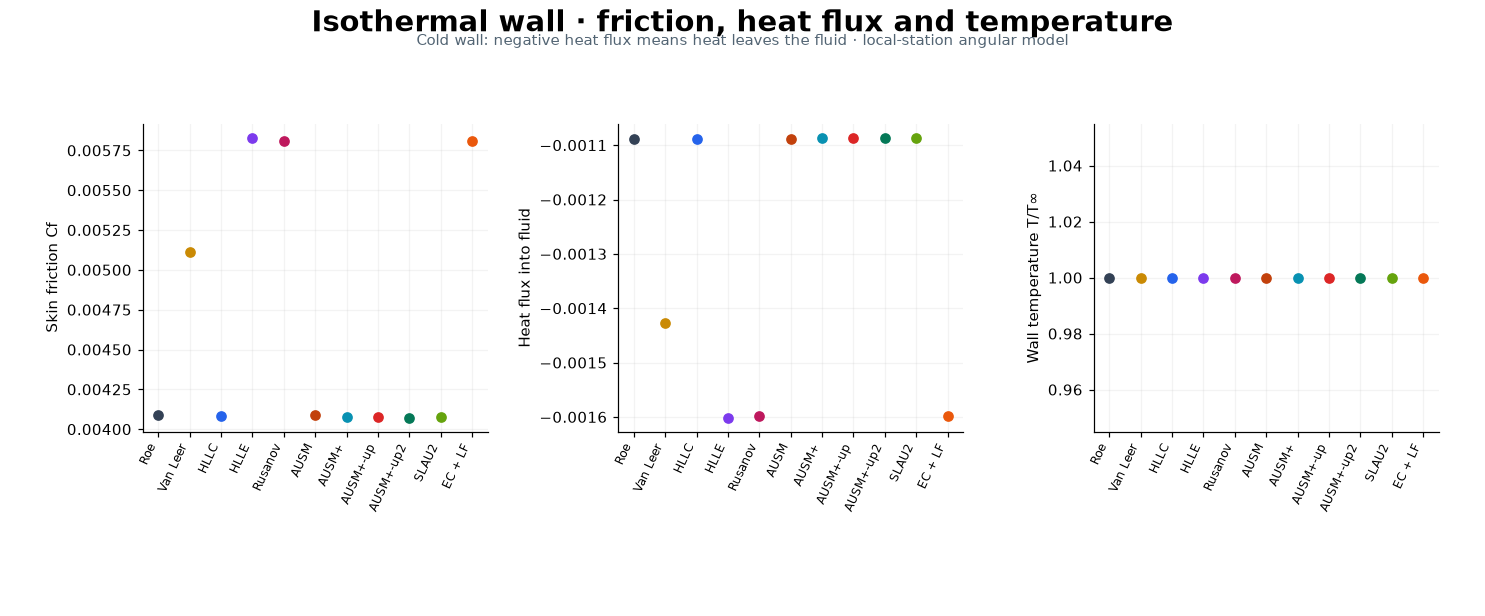

In [6]:
isothermal_runs = select(study, physics='isothermal')
show_table(isothermal_runs)
plot_properties(isothermal_runs, "isothermal-properties", "Viscous cone station · isothermal · all 11 fluxes")
plot_convergence(isothermal_runs, "isothermal-convergence", "Isothermal wall · all 11 convergence histories")
plot_wall_transport(isothermal_runs, "isothermal-wall-transport", "Isothermal wall · friction, heat flux and temperature")


## 5. Higher-order FV reconstruction · six choices

Hold HLLC, Mach 2.35 and 60 cells fixed, then compare constant, MUSCL-MC, CWENO3/5 and characteristic CWENO3/5.
Nominal smooth order does not guarantee high order through a shock or at a wall.


Flux,Reconstruction,Cells,Status,Final residual,p wall / p∞
HLLC,first,60,Accepted,1.776e-08,1.4306817
HLLC,muscl,60,Accepted,1.722e-08,1.3739703
HLLC,cweno3,60,Accepted,1.847e-08,1.3738895
HLLC,cweno5,60,Accepted,1.963e-08,1.3739058
HLLC,cweno3-char,60,Accepted,1.995e-08,1.3738816
HLLC,cweno5-char,60,Accepted,1.733e-08,1.3738894


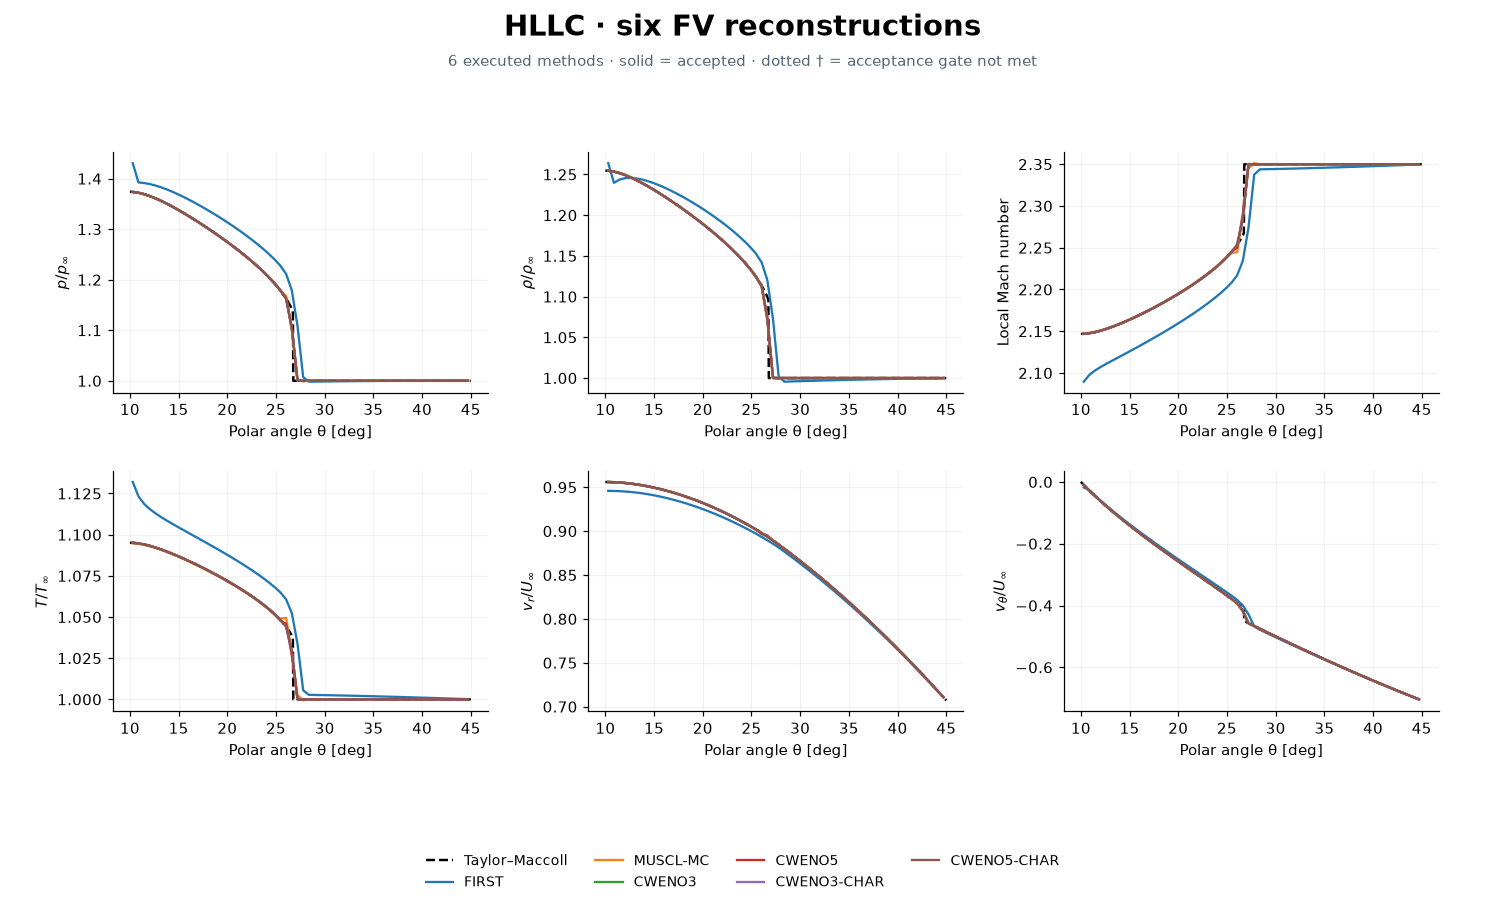

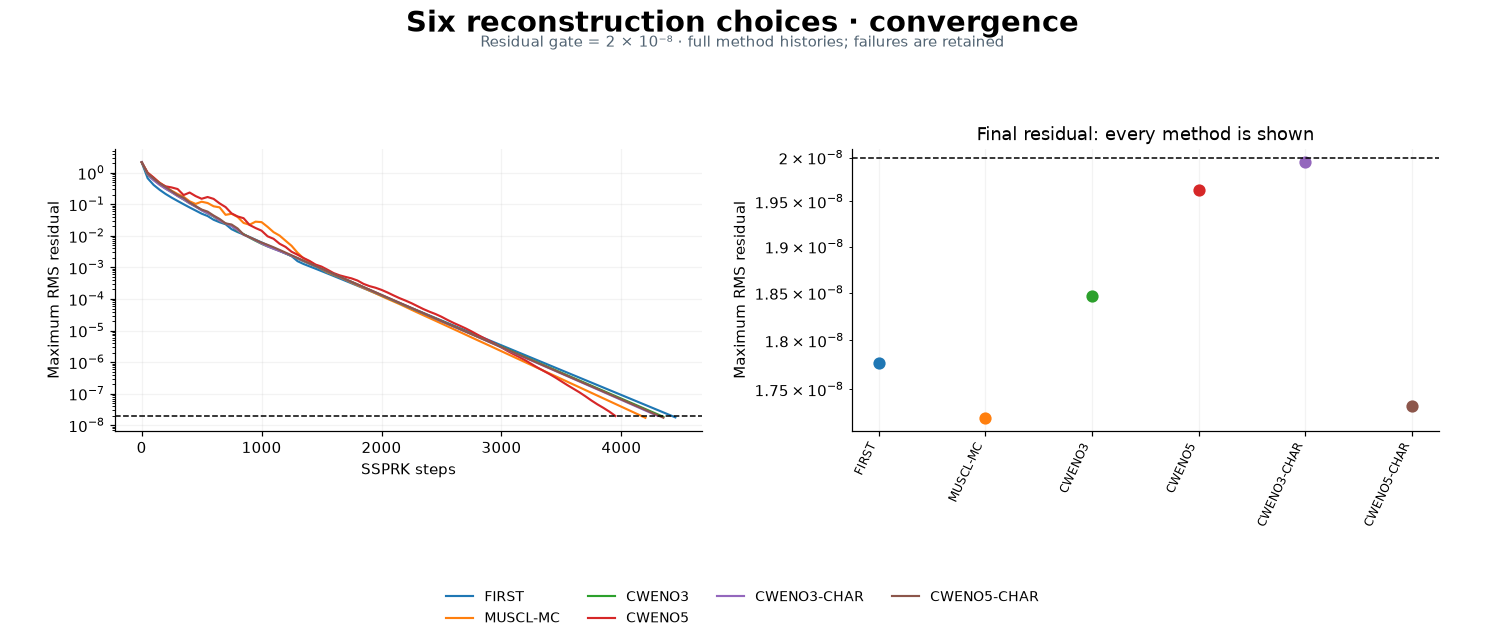

In [7]:
reconstruction_runs = select(study, group="reconstruction", physics="inviscid", mach=2.35)
show_table(reconstruction_runs)
plot_properties(reconstruction_runs, "reconstruction-properties", "HLLC · six FV reconstructions", group="reconstruction")
plot_convergence(reconstruction_runs, "reconstruction-convergence", "Six reconstruction choices · convergence", group="reconstruction")


## 6. Higher-order viscous operator and grid sensitivity

Characteristic CWENO5 and fourth-order interior diffusion: HLLC/AUSM+-up2 on 60, 120 and 240 cells, both thermal walls.
Every failed gate remains visible. The formally second-order wall closure limits global-order claims.


Flux,Reconstruction,Cells,Status,Final residual,p wall / p∞,Cf,q wall into fluid
AUSM+-up2,cweno5-char,120,Accepted,4.604e-09,4.3302254,0.00383474,-0
HLLC,cweno5-char,120,Accepted,2.962e-11,4.3333711,0.00383708,-0
AUSM+-up2,cweno5-char,240,Gate not met,3.563e-02,4.3327181,0.00383699,-0
HLLC,cweno5-char,240,Accepted,1.145e-08,4.3377971,0.00383821,-0
AUSM+-up2,cweno5-char,60,Accepted,7.494e-09,4.3211454,0.00383672,-0
HLLC,cweno5-char,60,Accepted,7.773e-09,4.3262608,0.00384018,-0


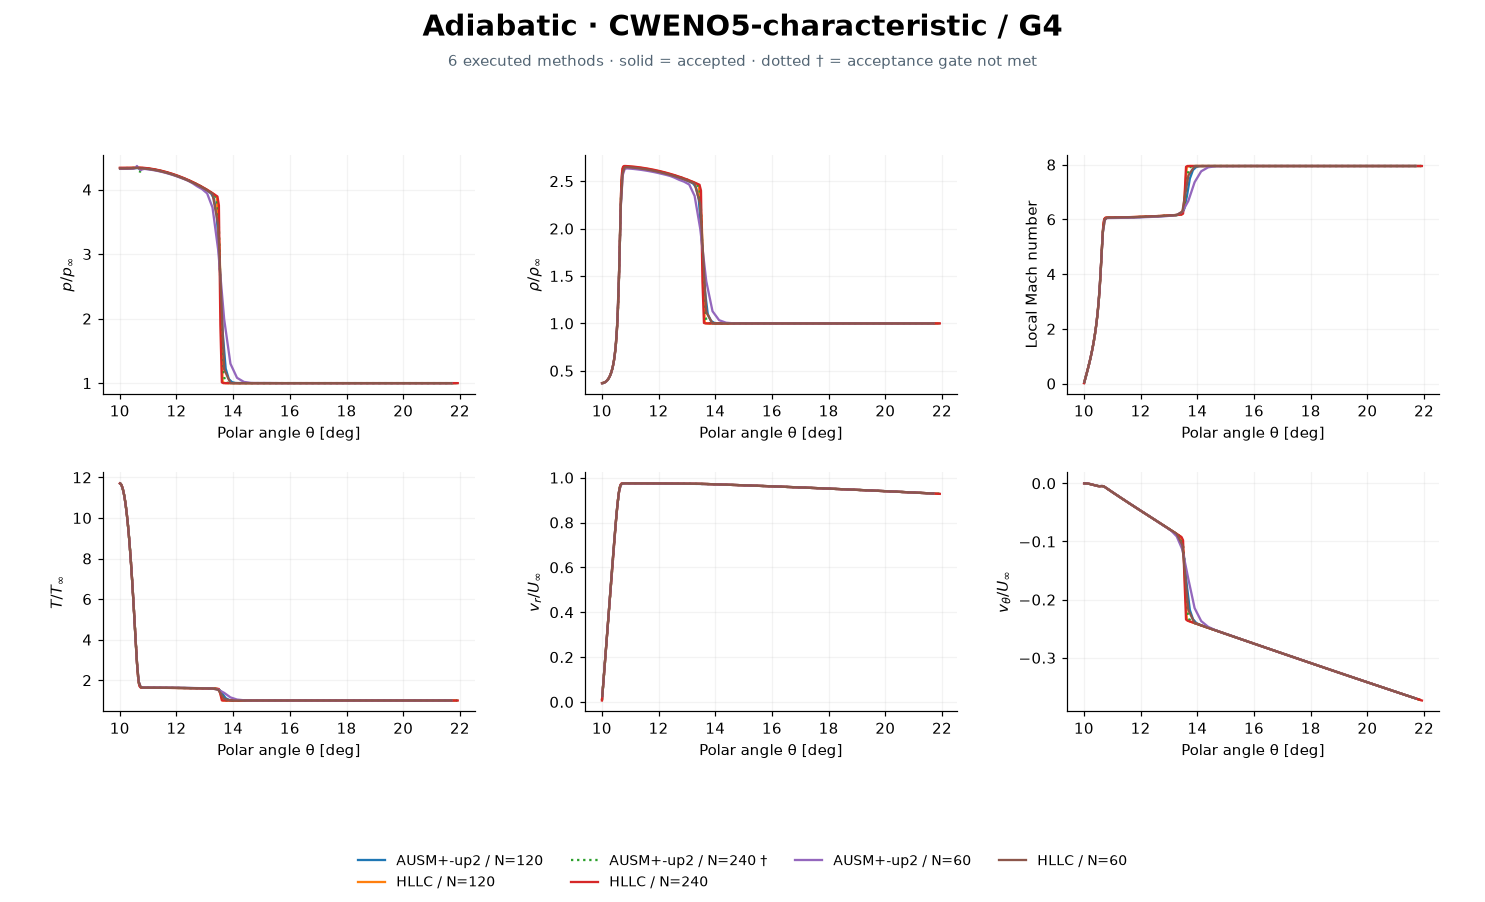

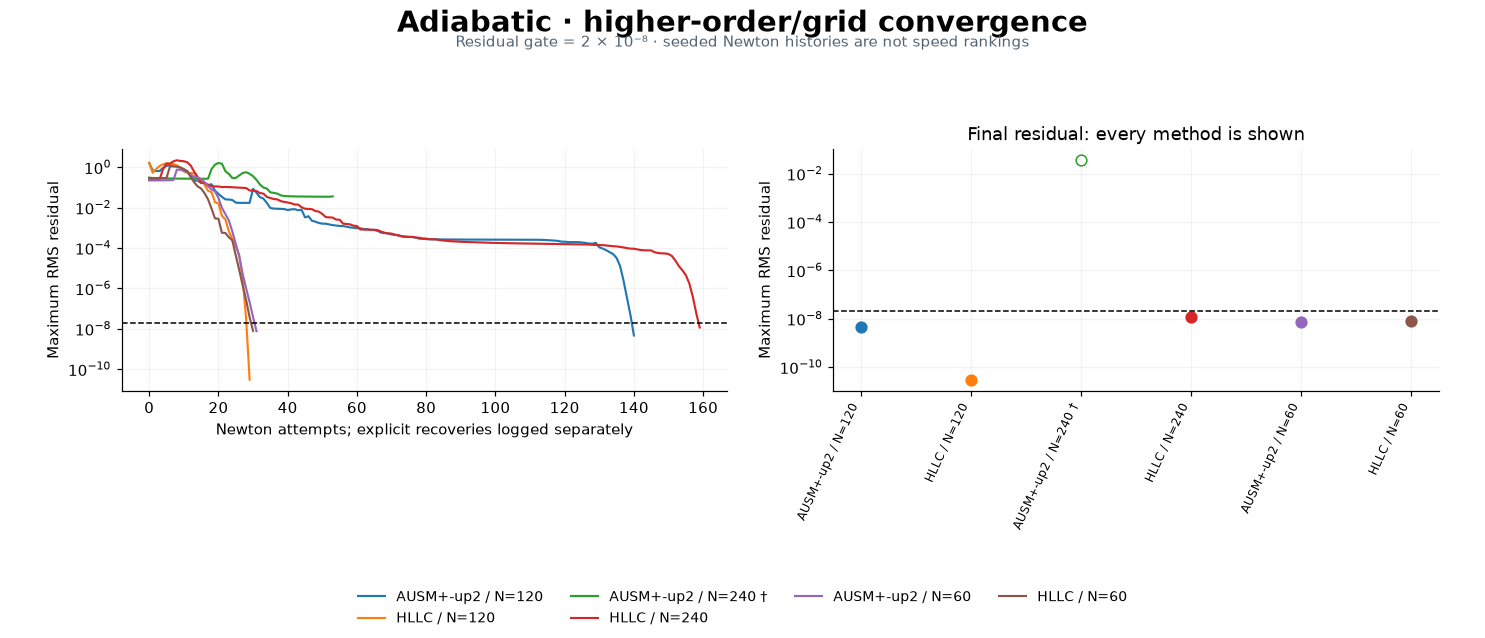

Flux,Reconstruction,Cells,Status,Final residual,p wall / p∞,Cf,q wall into fluid
AUSM+-up2,cweno5-char,120,Accepted,6.371e-11,4.1170779,0.00408291,-0.00111616
HLLC,cweno5-char,120,Accepted,1.389e-10,4.1141807,0.00407748,-0.00111472
AUSM+-up2,cweno5-char,240,Gate not met,1.009e-08,4.1221737,0.00410008,-0.00111745
HLLC,cweno5-char,240,Gate not met,1.257e-03,4.1201485,0.00409842,-0.00111715
AUSM+-up2,cweno5-char,60,Accepted,9.555e-09,4.1059423,0.00399239,-0.00108472
HLLC,cweno5-char,60,Accepted,3.089e-09,4.0976948,0.00395484,-0.00107518


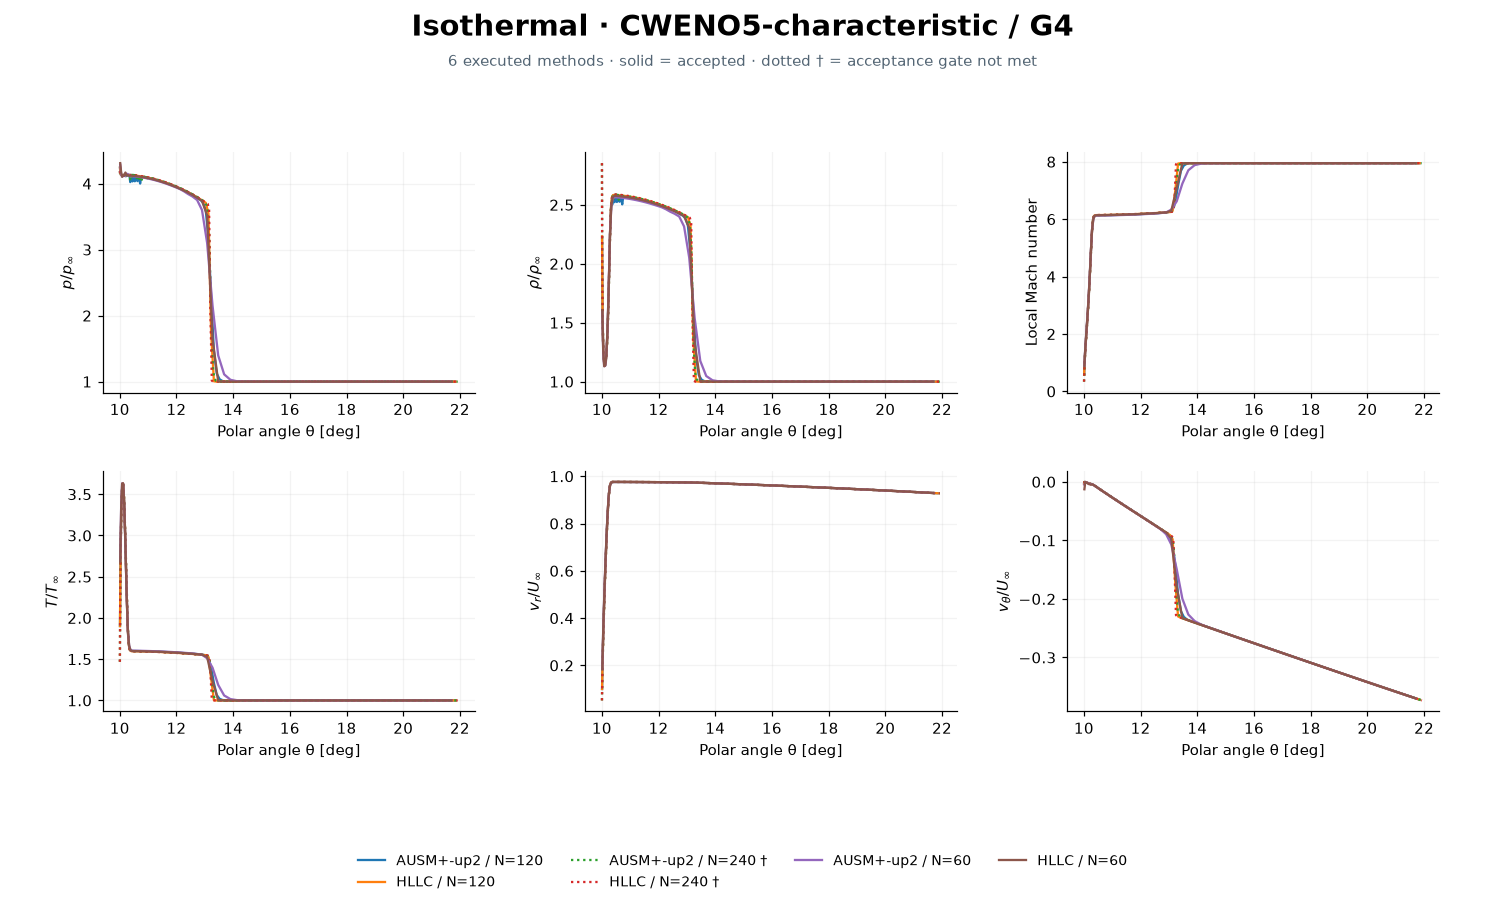

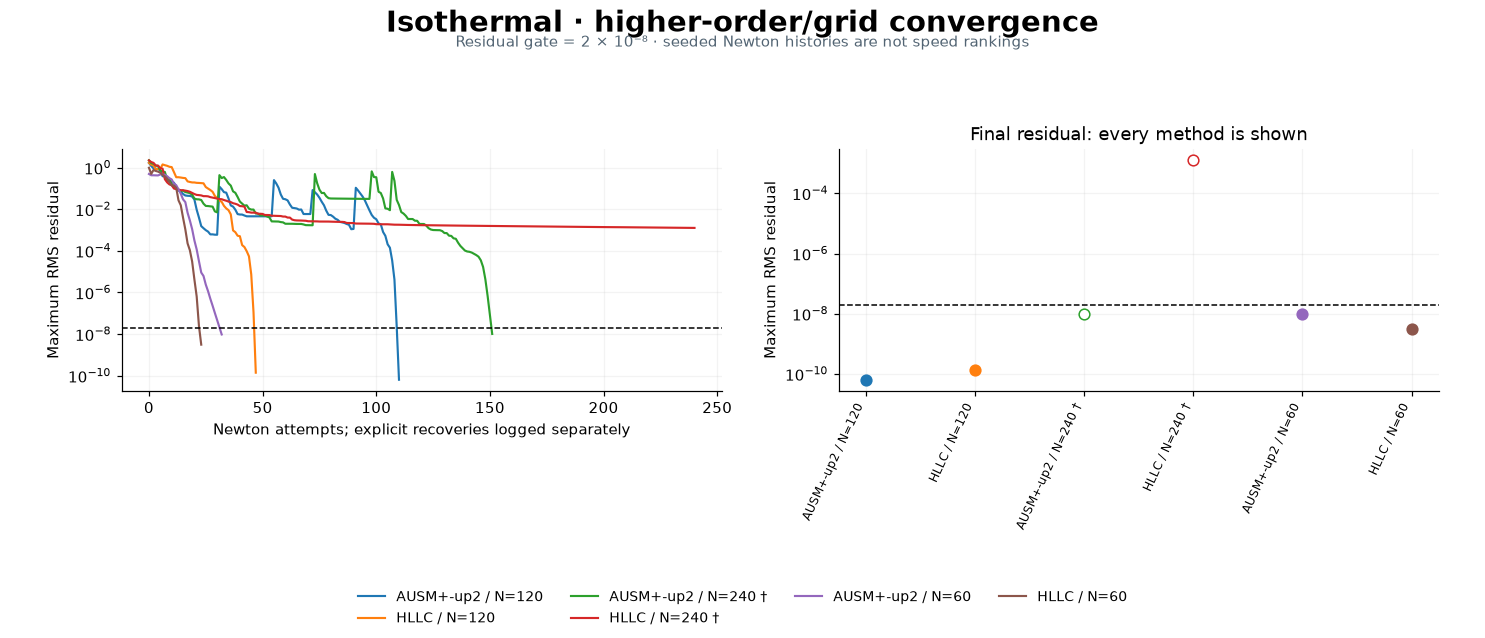

In [8]:
for wall in ("adiabatic", "isothermal"):
    high_order = select(study, group="viscous-high-order", physics=wall)
    show_table(high_order)
    plot_properties(high_order, wall+"-higher-order-properties", wall.capitalize()+" · CWENO5-characteristic / G4", group="viscous-high-order")
    plot_convergence(high_order, wall+"-higher-order-convergence", wall.capitalize()+" · higher-order/grid convergence", group="viscous-high-order")


## 7. Optional DG companion · all six degree/flux cases

DG degrees 0, 1 and 2 with HLLC and AUSM+-up2, Mach 2.35 and 40 elements. Both degree-zero cases passed;
the degree-one/two cone cases missed the full modal residual gate. Smooth measured orders near 2 and 3 do not resolve shock robustness.


Flux,Reconstruction,Cells,Status,Final residual,p wall / p∞
AUSM+-up2,DG degree 0,40,Accepted,1.777e-08,1.4404399
AUSM+-up2,DG degree 1,40,Gate not met,3.412e-02,1.3738475
AUSM+-up2,DG degree 2,40,Gate not met,1.064e-01,1.3738649
HLLC,DG degree 0,40,Accepted,1.749e-08,1.4157939
HLLC,DG degree 1,40,Gate not met,2.481e-02,1.3738763
HLLC,DG degree 2,40,Gate not met,3.004e-02,1.3739247


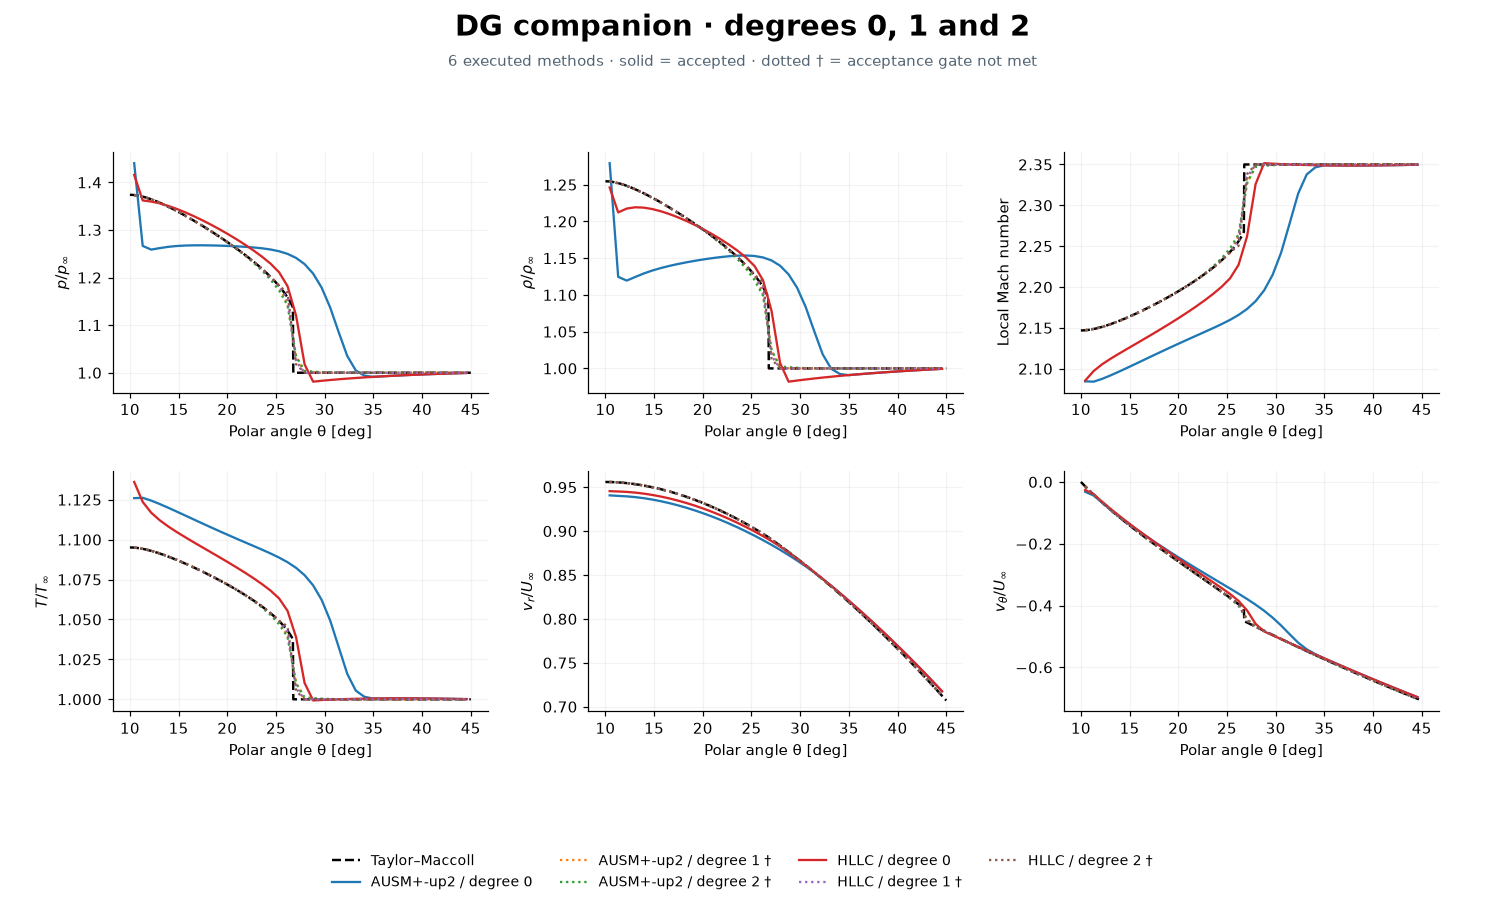

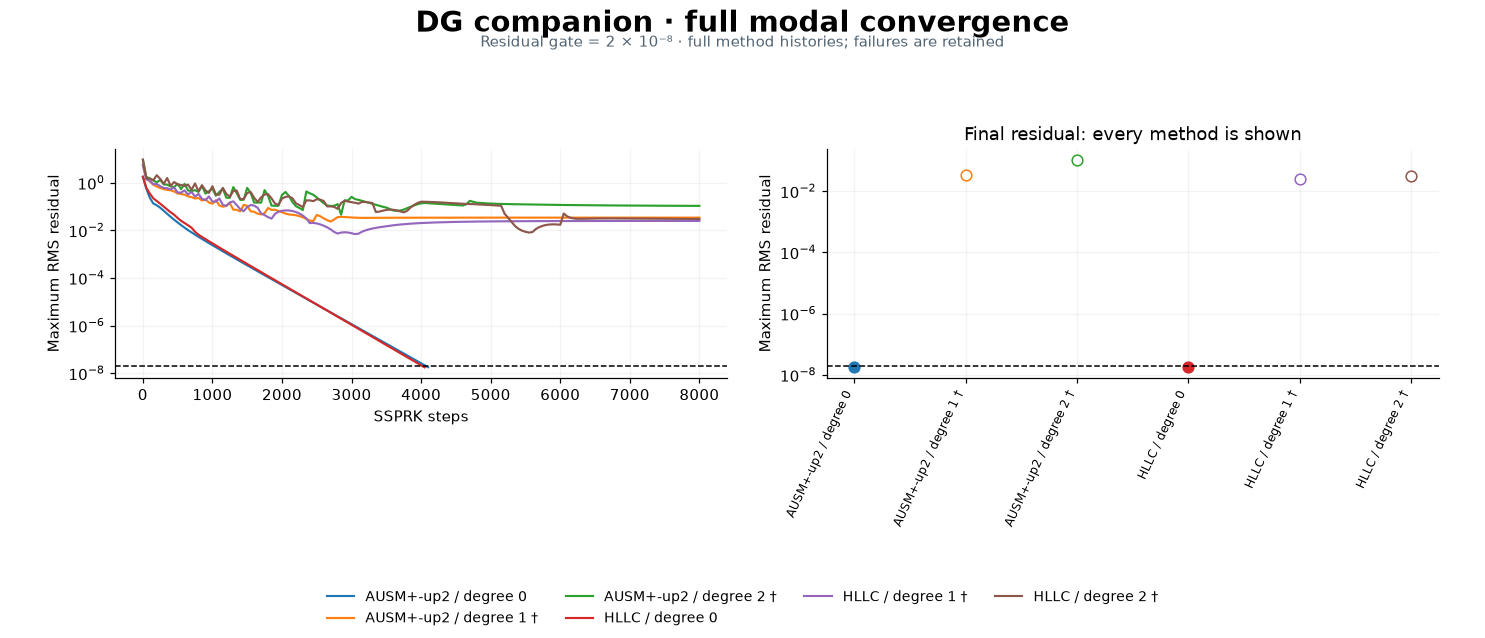

In [9]:
dg_runs = select(study, group="dg", physics="inviscid")
show_table(dg_runs)
plot_properties(dg_runs, "dg-properties", "DG companion · degrees 0, 1 and 2", group="dg")
plot_convergence(dg_runs, "dg-convergence", "DG companion · full modal convergence", group="dg")


## 8. Compute fresh answers — all 11 fluxes selected by default

The sections above show recorded executions. Enable `Run_fresh_comparison` to recompute answers in this session.
`Compare_all_fluxes` is **on by default**; turn it off only to investigate one method. Failures are reported while the remaining methods continue.
New flow and convergence figures follow the run. Fresh comparisons can take several minutes.


In [10]:
# @title Compute a new comparison {display-mode: "form"}
Run_fresh_comparison = False # @param {type:"boolean"}
Compare_all_fluxes = True # @param {type:"boolean"}
Physics = "inviscid" # @param ["inviscid", "adiabatic", "isothermal", "dg-inviscid"]
Flux = "hllc" # @param ["roe", "vanleer", "hllc", "hlle", "rusanov", "ausm", "ausm-plus", "ausm-up", "ausm-up2", "slau2", "ec-lf"]
Use_default_physics_case = True # @param {type:"boolean"}
Cells = 60 # @param {type:"integer"}
Mach = 2.35 # @param {type:"number"}
Outer_angle_deg = 45.0 # @param {type:"number"}
Reconstruction = "cweno3" # @param ["first", "muscl", "cweno3", "cweno5", "cweno3-char", "cweno5-char", "primitive-minmod"]
DG_degree = 1 # @param [0, 1, 2]
Viscous_gradient_order = 2 # @param [2, 4]
Reynolds = 420000.0 # @param {type:"number"}
Prandtl = 0.72 # @param {type:"number"}
Max_steps = 18000 # @param {type:"integer"}
Max_Newton_attempts = 180 # @param {type:"integer"}
fresh_results, fresh_failures = [], []
if Run_fresh_comparison:
    viscous = Physics in ("adiabatic", "isothermal")
    actual_mach = (7.95 if viscous else 2.35) if Use_default_physics_case else Mach
    actual_outer = (22 if viscous else 45) if Use_default_physics_case else Outer_angle_deg
    actual_reconstruction = ("primitive-minmod" if viscous else "cweno3") if Use_default_physics_case else Reconstruction
    (WORK/"fresh-results").mkdir(exist_ok=True)
    for method in (list(FLUXES) if Compare_all_fluxes else [Flux]):
        try:
            fresh_results.append(run_case(flux=method, physics=Physics, cells=Cells, mach=actual_mach,
                outer_deg=actual_outer, reconstruction=actual_reconstruction, degree=int(DG_degree),
                gradient_order=int(Viscous_gradient_order), reynolds=Reynolds, prandtl=Prandtl,
                max_steps=Max_steps, max_newton=Max_Newton_attempts, output_dir=WORK/"fresh-results"))
        except (ArithmeticError, RuntimeError, ValueError) as error:
            fresh_failures.append({"flux":method,"error":str(error)})
            print(method, "failed:", error)
    if fresh_results:
        show_table(fresh_results)
        plot_properties(fresh_results, "fresh-properties", "Fresh session · computed flow properties")
        plot_convergence(fresh_results, "fresh-convergence", "Fresh session · convergence")
    if fresh_failures:
        (WORK/"fresh-results/failures.json").write_text(json.dumps(fresh_failures, indent=2))
else:
    print("All recorded answers are displayed above. Enable the fresh comparison to recompute them.")


All recorded answers are displayed above. Enable the fresh comparison to recompute them.


## 9. Verification and export

The FV residual gate is below 2 × 10⁻⁸. Accepted Newton states also pass an independent explicit-drift check;
DG checks every modal coefficient. Full experimental/2-D viscous-cone validation remains open.


In [11]:
# @title Optional checks and downloads {display-mode: "form"}
Run_verification = False # @param {type:"boolean"}
Download_figures = False # @param {type:"boolean"}
if Run_verification:
    subprocess.check_call([sys.executable, str(WORK/"verify_extension.py")])
    subprocess.check_call([sys.executable, str(WORK/"verify_dg.py")])
if Download_figures:
    import shutil
    archive = shutil.make_archive(str(WORK/"conical-comparison-figures"), "zip", WORK/"notebook-figures")
    try:
        from google.colab import files
    except ImportError:
        print("Saved:", archive)
    else:
        files.download(archive)


## Source and further reading

Numerical modules in the file browser remain editable. [Source and equations](https://github.com/Ehsan-Roohi/Ehsan-Roohi/blob/main/courses/cfd-2/modern-python/conical/README.md),
[complete report](https://github.com/Ehsan-Roohi/Ehsan-Roohi/blob/main/courses/cfd-2/modern-python/conical/RESULTS.md), [viscous assumptions](https://github.com/Ehsan-Roohi/Ehsan-Roohi/blob/main/courses/cfd-2/modern-python/conical/VISCOUS.md), [DG limits](https://github.com/Ehsan-Roohi/Ehsan-Roohi/blob/main/courses/cfd-2/modern-python/conical/DG.md).
Original Fortran sources remain in the archive.

Primary references: [CWENO](https://arxiv.org/abs/1607.07319),
[AUSM+-up](https://doi.org/10.1016/j.jcp.2005.09.020),
[AUSM+-up2/SLAU2](https://doi.org/10.1016/j.jcp.2013.02.046),
[entropy flux](https://arxiv.org/abs/1209.4994),
[RKDG](https://helper.ipam.ucla.edu/publications/pcatut2005/pcatut_5477_reprint2.pdf).
